In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [2]:
import pandas as pd
import os
import sys
import pymc as pm
import pymc_bart as pmb
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from hyperion_utils import *


/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [32]:

def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'Hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True, aCv = False):
    myPredictorsDf = pd.read_csv('predictorsDf.csv')
    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'EMP' in x]
    myFilter = myPredictorsDf['groupe'] != 2

    # Get output data
    myXValue = myPredictorsDf.drop(columns= myColumns + ['CPC_SC3', 'CPC12', 'J0_SEX', 'SUBJID', 'BARTHEL_SC', 'SOFA_SC7', 'DS_DC', 'DAYS_ALIVE_30', 'J0_GLASGOW_CONTROLE', 'J0_CORDA_DOS'])
    myXValue = myXValue
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)
    if (aCv):
        skf = StratifiedKFold(n_splits=3, shuffle=True)
        return myPredictorsDf, myXValue, myYValue, skf
    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [58]:
myPredictorsDf.groupe.sum()

284.0

In [33]:
myPredictorsDf, X, y, skf = getTrainTestFunctions(aPredictedColumn = 'CPC12', 
                                                                         aTreatmentColumn = 'groupe', aSkipTemp = False, aCv = True) 

In [54]:
def bart_model_generate_and_evaluate(train_idx, test_idx):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
    X_train_transf = myPipeline.fit_transform(X_train, y_train)
    X_test_transf = myPipeline.transform(X_test)
    X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
    X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

    with pm.Model() as model:
        X_shared = pm.MutableData('X_shared', X_train_transf)
        y_shared = pm.MutableData('y_shared', y_train)
        u = pmb.BART('u', X = X_shared, Y= y_train, m=30)
        p = 1 / (1 + np.exp(-u))
        y_obs= pm.Bernoulli('y_obs', p=p, observed = y_shared)
        trace = pm.sample(100, return_inferencedata=True)

    with model:
        pm.set_data({'X_shared': X_train_transf, 'y_shared': y_train})
        p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
        # Calculate the mean predicted probability
        predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data
    
    threshold = 0.5
    predictions = (predicted_probs > threshold).astype(int)
    from sklearn.metrics import roc_auc_score, accuracy_score
    
    # Calculate ROC AUC
    roc_auc = roc_auc_score(y_train, predicted_probs)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_train, predictions)
    
    print(f'Training ROC AUC: {roc_auc:.2f}')
    print(f'Training Accuracy: {accuracy:.2f}')

    myXValueModified1 = X_train.copy()
    myXValueModified1['Hypothermia'] = 1.0
    myXValueModified2 = X_train.copy()
    myXValueModified2['Hypothermia'] = 0.0
    with model:
        pm.set_data({'X_shared': myPipeline.transform(myXValueModified1), 'y_shared': y_train})
        p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
        predicted_probs1 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data
    
    with model:
        pm.set_data({'X_shared': myPipeline.transform(myXValueModified2), 'y_shared': y_train})
        p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
        predicted_probs2 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data
    myYPred =  (predicted_probs1 - predicted_probs2)
    myYPred = predicted_probs
    myNewDf = pd.DataFrame()
    myNewDf['predicted_effect'] = myYPred
    low_third, upper_third, myNewDf = plotPredictedTreatmentEffect(myNewDf, 'bin__groupe')
    getTreatmentEffectDiffDataFrame(X_train_transf, y_train, myNewDf, 'CPC12', 'bin__groupe', False)

    with model:
        pm.set_data({'X_shared': X_test_transf, 'y_shared': y_test})
        p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
        predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data
    
    threshold = 0.5
    predictions = (predicted_probs > threshold).astype(int)
    from sklearn.metrics import roc_auc_score, accuracy_score
    
    # Calculate ROC AUC
    roc_auc = roc_auc_score(y_test, predicted_probs)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, predictions)
    
    print(f'Test ROC AUC: {roc_auc:.2f}')
    print(f'Test Accuracy: {accuracy:.2f}')

    myXValueModified1 = X_test.copy()
    myXValueModified1['Hypothermia'] = 1.0
    myXValueModified2 = X_test.copy()
    myXValueModified2['Hypothermia'] = 0.0
    with model:
        pm.set_data({'X_shared': myPipeline.transform(myXValueModified1), 'y_shared': y_test})
        p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
        predicted_probs1 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data
    
    with model:
        pm.set_data({'X_shared': myPipeline.transform(myXValueModified2), 'y_shared': y_test})
        p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
        predicted_probs2 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data
    myYPred =  (predicted_probs1 - predicted_probs2)
    myYPred = predicted_probs
    myNewDf = pd.DataFrame()
    myNewDf['predicted_effect'] = myYPred
    low_third, upper_third, myNewDf = plotPredictedTreatmentEffect(myNewDf, 'bin__groupe')
    getTreatmentEffectDiffDataFrame(X_test_transf, y_test, myNewDf, 'CPC12', 'bin__groupe', False)
    

Multiprocess sampling (4 chains in 4 jobs)
PGBART: [u]


Sampling 4 chains for 1_000 tune and 100 draw iterations (4_000 + 400 draws total) took 15 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [y_obs]


Training ROC AUC: 0.99
Training Accuracy: 0.92


Sampling: [y_obs]


Sampling: [y_obs]


...

Optimization terminated successfully.
         Current function value: 0.268509
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.266815
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 1.3145415987230535
p-value: 0.2515740175794446
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:                  CPC12   No. Observations:                  388
Model:                          Logit   Df Residuals:                      385
Method:                           MLE   Df Model:                            2
Date:                Sun, 30 Mar 2025   Pseudo R-squ.:                 0.01347
Time:                        18:06:46   Log-Likelihood:                -104.18
converged:                       True   LL-Null:                       -105.60
Covariance Type:            nonrobust   LLR p-value:                    0.2412
                      

Sampling: [u, y_obs]


Test ROC AUC: 0.83
Test Accuracy: 0.92


Sampling: [u, y_obs]


Optimization terminated successfully.
         Current function value: 0.255653
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.248515
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 2.7554545040935636
p-value: 0.09692326917825769
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:                  CPC12   No. Observations:                  193
Model:                          Logit   Df Residuals:                      190
Method:                           MLE   Df Model:                            2
Date:                Sun, 30 Mar 2025   Pseudo R-squ.:                 0.06411
Time:                        18:06:51   Log-Likelihood:                -49.341
converged:                       True   LL-Null:                       -52.721
Covariance Type:            nonrobust   LLR p-value:                   0.03405
                     

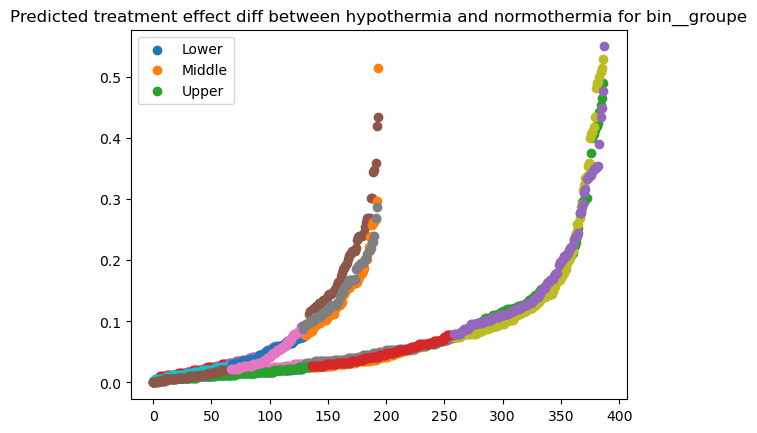

In [55]:
for train_idx, test_idx in skf.split(X, y):
    bart_model_generate_and_evaluate(train_idx, test_idx)

In [41]:
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [42]:

with pm.Model() as model:
    X_shared = pm.MutableData('X_shared', X_train_transf)
    y_shared = pm.MutableData('y_shared', y_train)
    u = pmb.BART('u', X = X_shared, Y= y_train, m=30)
    p = 1 / (1 + np.exp(-u))
    y_obs= pm.Bernoulli('y_obs', p=p, observed = y_shared)
    trace = pm.sample(100, return_inferencedata=True)
    # trace = az.from_netcdf('bart_model_tracedc.nc')
# Save trace 
# az.to_netcdf(trace, 'bart_model_tracedc.nc')

Multiprocess sampling (4 chains in 4 jobs)
PGBART: [u]


Sampling 4 chains for 1_000 tune and 100 draw iterations (4_000 + 400 draws total) took 15 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [10]:
import arviz as az
az.to_netcdf(trace, 'bart_model_tracedc.nc')

'bart_model_tracedc.nc'

In [43]:
with model:
    pm.set_data({'X_shared': X_train_transf, 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    # Calculate the mean predicted probability
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_train, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_train, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

Sampling: [y_obs]


ROC AUC: 0.99
Accuracy: 0.94


In [44]:
with model:
    pm.set_data({'X_shared': X_test_transf, 'y_shared': y_test})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

threshold = 0.5
predictions = (predicted_probs > threshold).astype(int)
from sklearn.metrics import roc_auc_score, accuracy_score

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, predicted_probs)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)

print(f'ROC AUC: {roc_auc:.2f}')
print(f'Accuracy: {accuracy:.2f}')

Sampling: [u, y_obs]


ROC AUC: 0.82
Accuracy: 0.92


In [45]:
myXValueModified1 = X_test.copy()
myXValueModified1['Hypothermia'] = 1.0
myXValueModified2 = X_test.copy()
myXValueModified2['Hypothermia'] = 0.0
with model:
    pm.set_data({'X_shared': myPipeline.transform(myXValueModified1), 'y_shared': y_test})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs1 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

with model:
    pm.set_data({'X_shared': myPipeline.transform(myXValueModified2), 'y_shared': y_test})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs2 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data



Sampling: [u, y_obs]


Sampling: [u, y_obs]


In [20]:
myXValueModified1 = X_train.copy()
myXValueModified1['Hypothermia'] = 1.0
myXValueModified2 = X_train.copy()
myXValueModified2['Hypothermia'] = 0.0
with model:
    pm.set_data({'X_shared': myPipeline.transform(myXValueModified1), 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs1 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data

with model:
    pm.set_data({'X_shared': myPipeline.transform(myXValueModified2), 'y_shared': y_train})
    p_pred = pm.sample_posterior_predictive(trace, var_names=['y_obs'])
    predicted_probs2 = p_pred['posterior_predictive']['y_obs'].mean(axis=0).mean(axis=0).data



Sampling: [y_obs]


Sampling: [y_obs]


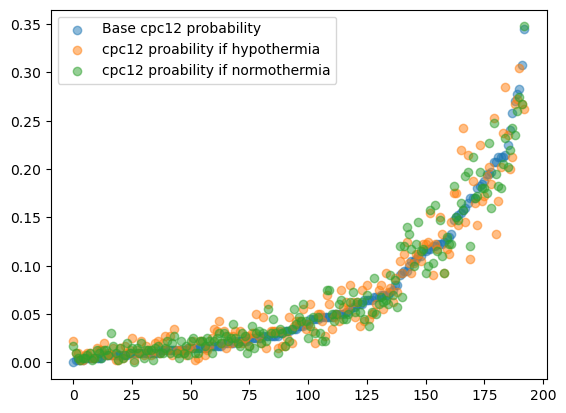

In [46]:
myYPred =  (predicted_probs1 - predicted_probs2)
myYPred = predicted_probs
myDfPreds = pd.DataFrame()
myDfPreds['base'] = predicted_probs
myDfPreds['group1'] = predicted_probs1
myDfPreds['group2'] = predicted_probs2
myDfPreds.sort_values(by=['base'], inplace=True)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['base'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group1'], alpha = 0.5)
plt.scatter(x = range(len(predicted_probs1)), y = myDfPreds['group2'], alpha = 0.5)
plt.legend(['Base cpc12 probability', 'cpc12 proability if hypothermia', 'cpc12 proability if normothermia'])


In [47]:
myNewDf = pd.DataFrame()
myNewDf['predicted_effect'] = myYPred

In [48]:
myNewDf

,predicted_effect
0,0.2400
1,0.0400
2,0.0800
3,0.0200
4,0.1250
...,...
188,0.0100
189,0.0575
190,0.0325
191,0.0900


Optimization terminated successfully.
         Current function value: 0.264271
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.263978
         Iterations 8
Likelihood ratio of test results:
Chi square statistic: 0.23820729222944692
p-value: 0.6255039114780607
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:                  CPC12   No. Observations:                  406
Model:                          Logit   Df Residuals:                      403
Method:                           MLE   Df Model:                            2
Date:                Sun, 30 Mar 2025   Pseudo R-squ.:                 0.02040
Time:                        17:41:33   Log-Likelihood:                -107.29
converged:                       True   LL-Null:                       -109.53
Covariance Type:            nonrobust   LLR p-value:                    0.1071
                     

0.6255039114780607

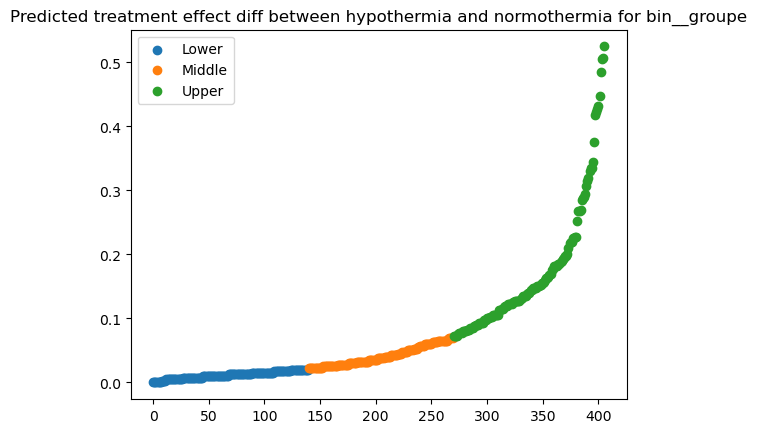

In [25]:
low_third, upper_third, myNewDf = plotPredictedTreatmentEffect(myNewDf, 'bin__groupe')
getTreatmentEffectDiffDataFrame(X_train_transf, y_train, myNewDf, 'CPC12', 'bin__groupe', False)

Optimization terminated successfully.
         Current function value: 0.267635
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.267615
         Iterations 7
Likelihood ratio of test results:
Chi square statistic: 0.007693187728960993
p-value: 0.9301065206334578
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:                  CPC12   No. Observations:                  193
Model:                          Logit   Df Residuals:                      190
Method:                           MLE   Df Model:                            2
Date:                Sun, 30 Mar 2025   Pseudo R-squ.:                 0.02025
Time:                        17:57:59   Log-Likelihood:                -51.653
converged:                       True   LL-Null:                       -52.721
Covariance Type:            nonrobust   LLR p-value:                    0.3439
                    

0.9301065206334578

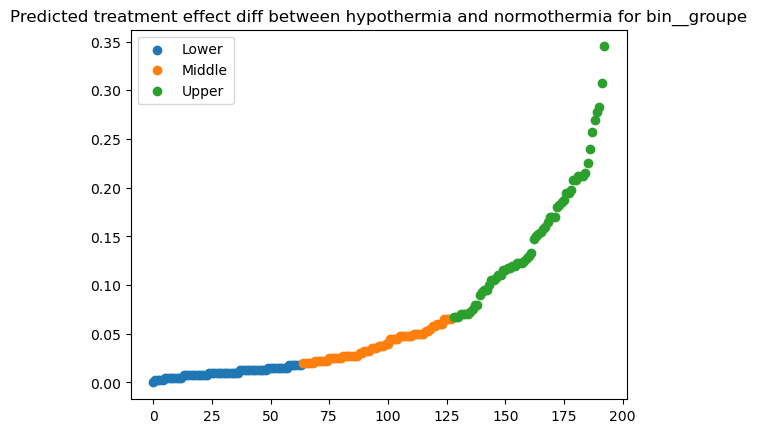

In [49]:
low_third, upper_third, myNewDf = plotPredictedTreatmentEffect(myNewDf, 'bin__groupe')
getTreatmentEffectDiffDataFrame(X_test_transf, y_test, myNewDf, 'CPC12', 'bin__groupe', False)

In [35]:
myData = pd.concat([X_train['Hypothermia'].reset_index(), myNewDf['predicted_effect_group'].reset_index(), y_train.reset_index()], axis=1)


In [39]:
myData.groupby(['Hypothermia', 'predicted_effect_group']).agg({'LastMGCSPositive': 'sum'})

LastMGCSPositive
Hypothermia predicted_effect_group                  
0           Lower                                215
            Middle                               192
            Upper                                195
1           Lower                                 35
            Middle                                40
            Upper                                 37